In [101]:
######## THIS CODE GIVES A MODEL FOR INFECTION AND THEN YOU CAN ADJUST THE COEFFICENTS USING  TIME-DEPENDENT IN ORDER TO USE THE LOCKDOWN COEFFICIENTS ########
########## PLEASE RUN THE CELLS IN ORDER ##############################################
######### Using this code you can regenerate Figure 12 #################################

####### Importing the required packages #######
using DataFrames
using CSV
using Plots
using ModelingToolkit, OrdinaryDiffEq, LinearAlgebra
using DifferentialEquations
using DataDrivenDiffEq
using DataDrivenSparse
using StatsPlots
using Statistics
using Distributions
using Dates
using DSP
using RecursiveArrayTools
using DiffEqParamEstim
using Optimization, OptimizationOptimJL
using OptimizationBBO, Optim
using ForwardDiff
using PenaltyFunctions
using Turing
using StableRNGs
using DataInterpolations
using ComponentArrays
using StatsBase
using Random
using Lux, SciMLSensitivity
using OptimizationOptimisers

In [102]:
#################### Making the Data #######################################
theme(:bright)
rng = StableRNG(20)

start_training=350
finish_training=680
##### specify the range you want to chop out for prediction
split_start= 585 
split_finish=split_start+22

begin
    raw_data=CSV.File("Thuringen_SIRD_2.csv") |> DataFrame
    data=Matrix(raw_data[:,[2, 3]])'
      
    s=size(data)[2]
    for i in 1:s
        data[1,i]=mean(data[1,max(1,i-5):min(s,i)])
    end
    ############# Beta distribution

    function factors(α, β, n) ## Beta distribution, coefficients for n days needed (Infected)
        d=Beta(α, β)
        max=pdf(d, mode(d))
        step=1/(n+2-1)
        steps=collect(0.0:step: 1.0)
        coefs=zeros(length(steps))
        for i in eachindex(coefs)
            coefs[i]=pdf(d,steps[i])/max
        end
        return steps[2:end-1], coefs[2:end-1]
    end

    n=21  #### number of days that infection rate of each patient changes
    vals, cofs=factors(2.5,4.5,n) #### α=1.5 and β=2.5, we can change the curve shape by changing α and β

    ###############################  factors should be  used ######################

    infectiveness=zeros(size(data)[2],1);
    infectiveness=DSP.conv(cofs, data[1,:])[1:length(infectiveness)]
   
    #smoothing the infectiveness
    for i in eachindex(infectiveness)
        infectiveness[i]=mean(infectiveness[max(i-4,1):min(end, i)])
    end

  
    data1=copy(data)
    data1[2,:]=infectiveness
    
    Max_data1=[maximum(data1[i,1:end]) for i in 1:size(data1)[1]]
    Min=0
    for i in 1:size(data1)[1]
        for j in 1:size(data1)[2]
            data1[i,j]=(data1[i,j]-Min)/(Max_data1[i]-Min)
        end
    end 
    
    data2=data1[:,start_training:split_start]
    data3=data1[:,split_finish:finish_training]
    
    X1=copy(data2);
    X2=copy(data3);
end

2×74 Matrix{Float64}:
 0.276049  0.288452  0.30237   0.315362  …  0.566087  0.5488    0.530753
 0.14047   0.148966  0.157826  0.167041     0.888634  0.874853  0.860613

In [103]:
############################# Making control signal ########################
begin
    v_raw_data=CSV.File("Thuringen_daily_vaccination.csv") |> DataFrame
    v_data=Matrix{Float64}(v_raw_data[:,3:5])'

   
    ####  weekly averaging
     avg_days=7
    s=size(v_data)
    weekly=Matrix{Float64}(undef,s[1], s[2])
    for i in 1:size(v_data)[1]
        weekly[i,:]=[mean(v_data[i, max(j-avg_days,1):j]) for j in 1:s[2]]'
    end
    #avg_days=7
   
    ############# beta distribution  

    n=35 ## number of days needed to reach the peak of antibody and then goes down after vaccination
    vvals, vcofs=factors(3,4,n) #### α=4 and β=4, we can change the curve shape by changing α and β


    ###############################  factors should be reversed and used ######################
    dose1=zeros(size(v_data)[2],1);
    dose2=zeros(size(v_data)[2],1);
    dose3=zeros(size(v_data)[2],1);

    vcofs1=reverse(reverse(vcofs))
    for i in 1:lastindex(dose1)
        for j in 1:min(n,i)-1
            dose1[i]=dose1[i] + weekly[1, i-j] * vcofs1[j]
            dose2[i]=dose2[i] + weekly[2, i-j] * vcofs1[j]
            dose3[i]=dose3[i] + weekly[3, i-j] * vcofs1[j]
        end 
    end

    dose11=zeros(size(raw_data)[1],1);
    dose21=zeros(size(raw_data)[1],1);
    dose31=zeros(size(raw_data)[1],1);

    difference=Dates.value(v_raw_data[1,1]-raw_data[1,1])
    
    for i in difference+1:lastindex(dose11)
        dose11[i]=dose1[i-difference]
        dose21[i]=dose2[i-difference]
        dose31[i]=dose3[i-difference]
    end

    antibody=dose11.+dose21.+ dose31
    
    Max_antibody=maximum(antibody)
    Min=0#minimum(v_data)
    for i in 1:size(antibody)[1]       
        antibody[i]=(antibody[i]-Min)/(Max_antibody-Min)
    end
    
    control=vcat(antibody'); 
    control1=vcat(antibody[start_training:split_start]');
    control2=vcat(antibody[split_finish:finish_training]');

end

1×74 Matrix{Float64}:
 0.172384  0.173123  0.173651  0.173936  …  0.78242  0.749704  0.718941

In [105]:
######################## definition and solving of the problem ##################
begin
    tick=100_000
    t1=collect(0.0:1/tick:(split_start-start_training)/tick);
    itp_method=InterpolationMethod(LinearInterpolation)

    sir_problem1=ContinuousDataDrivenProblem(X1, t1, itp_method, U = control1)

    t2=collect(0.0:1/tick:(finish_training-split_finish)/tick);
    
    final_data=(prob1=(X=X1, t=t1, itp_method, U=control1), prob2=(X=X2, t=t2,  itp_method, U=control2))
    sir_problem=ContinuousDataset(final_data)#(sir_problem1, sir_problem2

    @variables u[1:2] c[1:1]
    u = collect(u)
    c = collect(c)

    if start_training==1
        h = Num[polynomial_basis([u; c], 1);]
    else
        h = Num[polynomial_basis([u; c], 2);]
    end

    basis = Basis(h, u, controls=c)
    

    ### choosing STLSQ as an optimizer
    ### STLSQ is a sparsifying algorithm that cause the solve function to call its "Sindy" method ###
    opt = STLSQ(exp10.(-3:0.01:+5))


    #sampler = DataProcessing(split = 0.7, shuffle=true, batchsize = 30, rng = rng)

    options = DataDrivenCommonOptions(maxiters = 1000, 
                                  normalize = DataNormalization(ZScoreTransform),
                                  selector = bic, digits = 3)

    ddsol = solve(sir_problem, basis, opt, options=options);
   
end

"DataDrivenSolution{Float64}"

In [111]:
################## recovering the dynamic  ########################
window=6
begin
    ##### range of prediction ####
    newdays=window
    start=split_start+newdays
    finish=split_finish
    
    
    res=ddsol
    sys = get_basis(res)
    

    # Optimal parameters
    p_opt = get_parameter_values(sys)
    
    z0=data1[:,start]

    ztspan=(start/tick,finish/tick)

    u=control
    tsteps = range(0.0, 706/tick, length = 707)
    A=LinearInterpolation(u,tsteps);


    function get_dose1(t)
        return A(t)[1]
    end

    function get_total_antibody(t)
        down=control[1, Int(round(t*tick+1, RoundDown))]
        up=control[1, Int(round(t*tick+1, RoundUp))]
        down_co=t*tick-round(t*tick,RoundDown)
        up_co=1-down_co
        control_in_t=down_co*down+up_co*up
        return control_in_t
    end

    # Generate a closure on the system 
    f_recovered = let doese_1 = get_dose1
       (x, p, t) -> sys(x, p, t, [doese_1.(t)])
    end
    f_recovered1 = let doese_1 = get_total_antibody
        (x, p, t) -> sys(x, p.+p_opt, t, [doese_1.(t)])
    end    
end

#188 (generic function with 1 method)

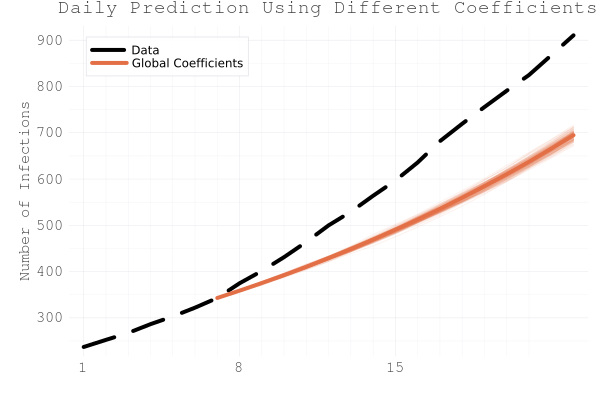

In [107]:
#################### Making projection using Global Coefficients #########################
ptest=plot(data1[1,start-window:finish]*Max_data1[1], label="Data", lw=4, color=:black, ls=:dash, title="Daily Prediction Using Different Coefficients",  legend=:topleft,
             yminorticks=2, xminorticks = 7, xticks=1:7:finish-start+1)
p_opt = get_parameter_values(sys)
begin
    theme(:bright)
    raw_data_end=CSV.File("Thuringen_SIRD_raw_2.csv") |> DataFrame
    data_end=Matrix(raw_data_end[:,[2, 3]])'
    t_step=1/tick
    beta=1.0
    
    g(u,p,t)=beta*u   #### stochastic function and its parameters

    ################## StatsPlots ################
    y1 = fill(NaN, finish-start+1, 1000);
    y2 = fill(NaN, finish-start+1, 1000);

    for i  in 1:1000
        prediction_prob = SDEProblem(f_recovered, g, z0, ztspan, p_opt)
        prediction = solve(prediction_prob, EM(), dt=t_step)
        M=Matrix(prediction)
      
        y1[:,i]=max.(M[1,:].-(z0[1]-data1[1,start]),0)       
        y2[:,i]=M[2,:]
        
    end
    
    ptest=errorline!(1+window:finish-start+1+window, y1[:,:]*Max_data1[1], errorstyle=:plume, label="Global Coefficients",
                     lw=4, left_margin = 5Plots.mm, bottom_margin = 5Plots.mm, ylabel="Number of Infections",
                     titlefont=font(10,"Arial"), guidefont = font(8,"Arial"), 
                     ytickfont=font(8, "Arial"), xtickfont=font(8, "Arial"))
    
    
end

In [108]:
############################################ Time-dependent Coefficient Adjustment #######################################

p1=get_parameter_values(sys);
true_params = p1

p=zeros(size(p1));
all_prms=[]

prms=[];
[push!(prms, p1) for _ in 1:10]
window=6;
for step in 1:finish_training-start_training-window-1 #-180:20#
    new_data=data1[:,start_training+step:start_training+window+step]

    u0=new_data[:,1]
    tspan=((start_training+step)/tick, (start_training+window+step)/tick)
    t=collect((start_training+step)/tick:1/tick:(start_training+window+step)/tick)

    # Define the objective function for optimization
    function objective_function(params, data, alpha)
        y_observed = data
        prob = ODEProblem(f_recovered, u0, tspan, params)
        sol = solve(prob, saveat=1/tick)
        y_predicted = sol(t)
        error = y_observed .- y_predicted
        tmp_prms=copy(prms)
        push!(tmp_prms, params)
        tmp_prms=reduce(hcat, tmp_prms)
        tv_penalty=0
        for k in 1:length(params)
            tv_penalty+=sum(diff(tmp_prms[k,:]))
        end

        return sum(error.^2) + alpha * tv_penalty  # alpha is the regularization strength
    end
    

    
    true_params = p1
    data =new_data

    # Initial guess for ODE parameters
    initial_guess = p1 

    # Regularization strength
    alpha =sum(abs.(p_opt))exp10(-30)

    
    options = Optim.Options(iterations=100)
    result = Optim.optimize(params -> objective_function(params, data, alpha), initial_guess, LBFGS(), options)

    # Extract the optimized parameters
    optimized_params = Optim.minimizer(result)
    push!(all_prms, optimized_params)
    p1=optimized_params
    push!(prms, optimized_params)
    popfirst!(prms)

end
finial_prms=reduce(hcat, all_prms);

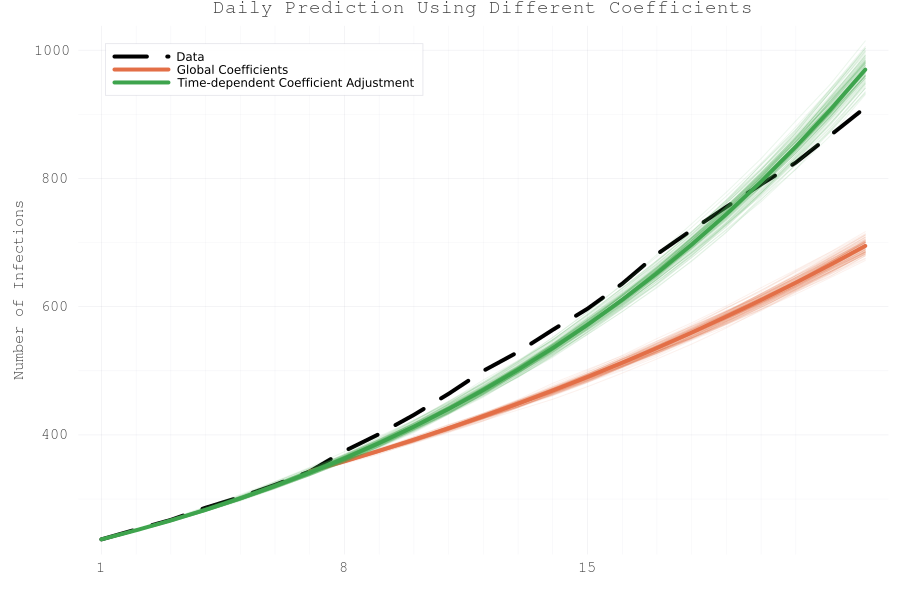

In [109]:
#################### Making projection using the Time-dependently adjusted coefficients #########################
p_opt2=finial_prms[:,split_start-start_training+1]#

start = split_start
z0=data1[:,start]
ztspan=(start/tick,finish/tick)

begin
    theme(:bright)
    raw_data_end=CSV.File("Thuringen_SIRD_raw_2.csv") |> DataFrame
    data_end=Matrix(raw_data_end[:,[2, 3]])'
    t_step=1/tick
    beta=1
    
    g(u,p,t)=beta*u   #### stochastic function and its parameters

    ################## StatsPlots ################
    y1 = fill(NaN, finish-start+1, 1000);
    y2 = fill(NaN, finish-start+1, 1000);

    for i  in 1:1000
        prediction_prob = SDEProblem(f_recovered, g, z0, ztspan, p_opt2)
        prediction = solve(prediction_prob, EM(), dt=t_step)
        M=Matrix(prediction)

       
        y1[:,i]=max.(M[1,:].-(z0[1]-data1[1,start]),0)
              
        y2[:,i]=M[2,:]
        
    end
    
    ptest=errorline!(1:finish-start+1, y1[:,:]*Max_data1[1], errorstyle=:plume, label="Time-dependent Coefficient Adjustment", size=(900,600),
                     lw=4, left_margin = 5Plots.mm, bottom_margin = 5Plots.mm, ylabel="Number of Infections",
                     titlefont=font(10,"Arial"), guidefont = font(8,"Arial"), 
                     ytickfont=font(8, "Arial"), xtickfont=font(8, "Arial"))
    
end

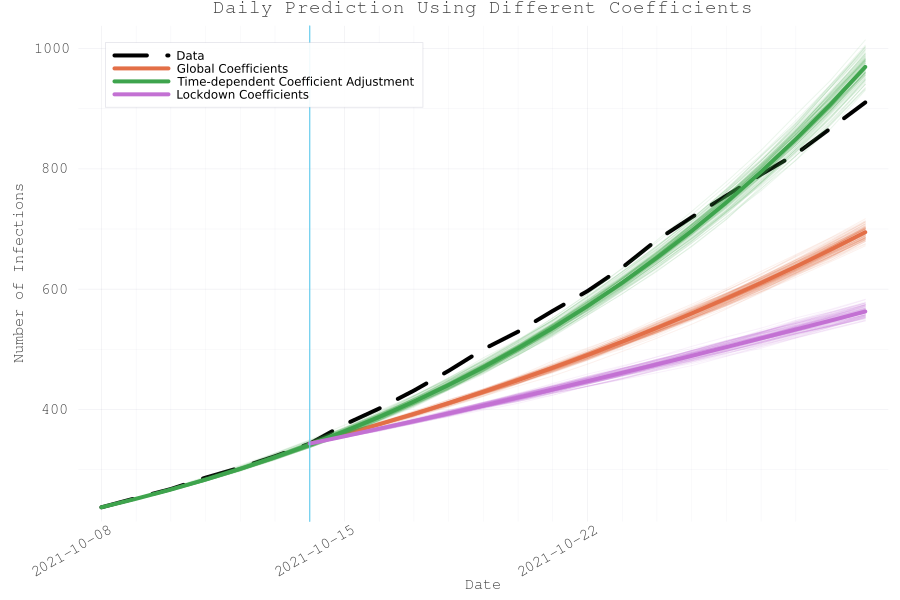

In [ ]:
#################### Making projection using the Lockdown coefficients from Time-dependently adjusted coefficients #########################
###### Figure 12 #######
p_opt2=finial_prms[:,44]

start = split_start+window
z0=data1[:,start]
ztspan=(start/tick,finish/tick)

begin
    theme(:bright)
    raw_data_end=CSV.File("Thuringen_SIRD_raw_2.csv") |> DataFrame
    data_end=Matrix(raw_data_end[:,[2, 3]])'
    t_step=1/tick
    beta=1
    
    g(u,p,t)=beta*u   #### stochastic function and its parameters

    ################## StatsPlots ################
    y1 = fill(NaN, finish-start+1, 1000);
    y2 = fill(NaN, finish-start+1, 1000);

    for i  in 1:1000
        prediction_prob = SDEProblem(f_recovered, g, z0, ztspan, p_opt2)
        prediction = solve(prediction_prob, EM(), dt=t_step)
        M=Matrix(prediction)

       
        y1[:,i]=max.(M[1,:].-(z0[1]-data1[1,start]),0)
              
        y2[:,i]=M[2,:]
        
    end
    
    ptest=errorline!(1+window:finish-start+1+window, y1[:,:]*Max_data1[1], errorstyle=:plume, label="Lockdown Coefficients", size=(900,600),
                     lw=4, left_margin = 5Plots.mm, bottom_margin = 5Plots.mm, ylabel="Number of Infections",
                     titlefont=font(10,"Arial"), guidefont = font(8,"Arial"), 
                     ytickfont=font(8, "Arial"), xtickfont=font(8, "Arial"))
    dates=raw_data[split_start:split_finish+1,1];
    plot!(ptest,xformatter= x->Dates.format(dates[Int(round(x, RoundDown))], "yyyy-mm-dd"), xrot=30, xlabel="Date",
             yminorticks=2, xminorticks = 7, xticks=1:7:finish-start+2)
    plot!([window+1], seriestype=vline, label=false)
end